# Merged Data Analysis


#### ANALYSIS ONLY - NO PROCESSING

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data Loading & Overview


In [ ]:
data_path = "000000 Final Data/eastnor/3_eobs_ecmwf_merged_with_seasons.csv"
df = pd.read_csv(data_path)

# Convert time to datetime
df['time'] = pd.to_datetime(df['time'])
display(df.head(3))

✓ Data loaded successfully
  Shape: (368, 19)
  Time range: 1993-03-31 00:00:00 to 2023-12-31 00:00:00
  Seasons: ['Spring' 'Summer' 'Fall' 'Winter']

First 3 rows:


,time,season,eobs_press,eobs_press_-1,eobs_press_-2,eobs_precip,eobs_precip_-1,eobs_precip_-2,eobs_temp,eobs_temp_-1,eobs_temp_-2,eobs_wet_day_frequency,eobs_spi_1_values,ecmwf_temp_ensmean,ecmwf_precip_ensmean,ecmwf_press_ensmean,ecmwf_temp_ensvar,ecmwf_precip_ensvar,ecmwf_press_ensvar
0,1993-03-31,Spring,1014.50,1018.14,998.95,6.10,25.70,38.97,-3.91,-4.46,-5.26,0.12,-1.86,-6.82,45.68,1009.98,1.78,232.81,34.73
1,1993-04-30,Spring,1014.27,1014.50,1018.14,9.87,6.10,25.70,0.90,-3.91,-4.46,0.15,-1.33,-2.25,59.95,1008.79,0.94,254.56,9.66
2,1993-05-31,Spring,1015.97,1014.27,1014.50,82.58,9.87,6.10,7.25,0.90,-3.91,0.43,1.12,5.87,74.59,1017.76,1.76,1214.23,4.81


## Dataset Structure


In [ ]:
eobs_base = [c for c in df.columns if c.startswith('eobs_') and '-' not in c]
eobs_lag = [c for c in df.columns if c.startswith('eobs_') and '-' in c]
ecmwf_mean = [c for c in df.columns if 'ecmwf_' in c and 'ensmean' in c]
ecmwf_var = [c for c in df.columns if 'ecmwf_' in c and 'ensvar' in c]

## Basic Statistics by Season


In [ ]:
key_vars = ['eobs_temp', 'eobs_precip', 'eobs_press', 'eobs_spi_1_values']

for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    season_df = df[df['season'] == season]
    print(f"\n{season} (n={len(season_df)} months):")
    for var in key_vars:
        mean = season_df[var].mean()
        std = season_df[var].std()

# Data Quality Checks


In [ ]:
total_nans = df.isnull().sum().sum()

duplicates = df.duplicated(subset=['time']).sum()

outlier_vars = ['eobs_temp', 'eobs_precip', 'eobs_press']
for var in outlier_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[var] < (Q1 - 1.5 * IQR)) | (df[var] > (Q3 + 1.5 * IQR))).sum()
    pct = 100 * outliers / len(df)

DATA QUALITY CHECKS

✓ Check 1 - NaN values: 0
✓ Check 2 - Duplicate times: 0

✓ Check 3 - Outlier detection (IQR method):
  eobs_temp           :   0 outliers (0.0%)
  eobs_precip         :   6 outliers (1.6%)
  eobs_press          :  24 outliers (6.5%)


# Univariate Analysis


## Distributions by Season


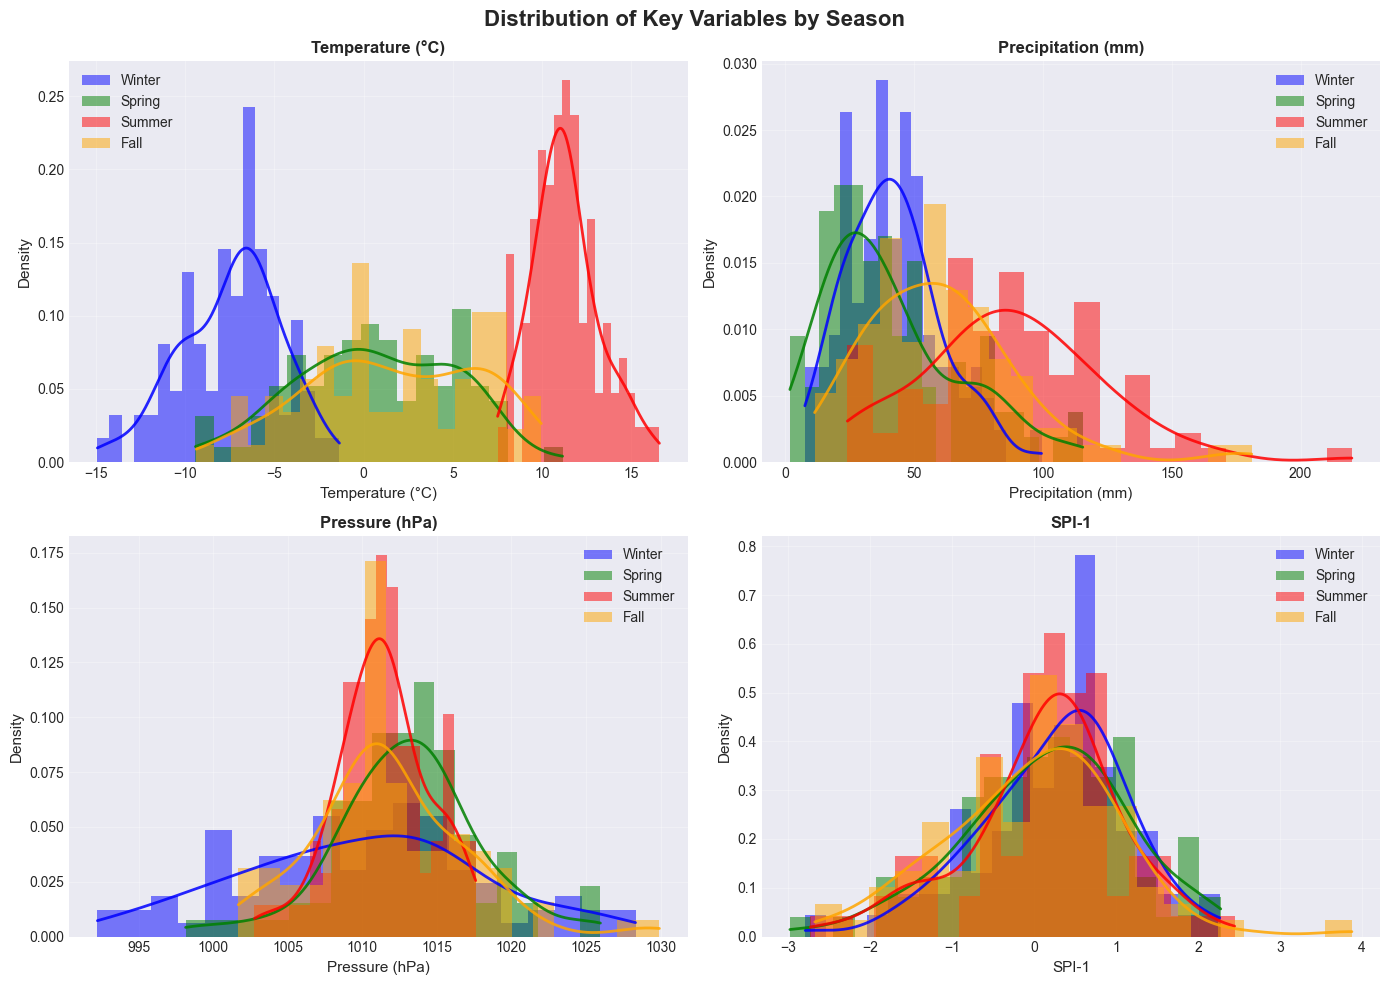

✓ Distribution plots complete


In [ ]:
import scipy.stats as stats
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Variables by Season', fontsize=16, fontweight='bold')

variables = [
    ('eobs_temp', 'Temperature (°C)', axes[0, 0]),
    ('eobs_precip', 'Precipitation (mm)', axes[0, 1]),
    ('eobs_press', 'Pressure (hPa)', axes[1, 0]),
    ('eobs_spi_1_values', 'SPI-1', axes[1, 1])
]

colors = {'Winter': 'blue', 'Spring': 'green', 'Summer': 'red', 'Fall': 'orange'}

for var, title, ax in variables:
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        season_data = df[df['season'] == season][var].dropna()
        if len(season_data) == 0:
            continue
        
        # Plot histogram
        ax.hist(season_data, bins=20, alpha=0.5, label=season, color=colors[season], density=True)
        
        # KDE/continuous density estimate
        try:
            kde = stats.gaussian_kde(season_data)
            x_min, x_max = season_data.min(), season_data.max()
            x_vals = np.linspace(x_min, x_max, 500)
            ax.plot(x_vals, kde(x_vals), color=colors[season], linewidth=2, alpha=0.85)
        except Exception as e:
            pass
    
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Time Series of Key Variables


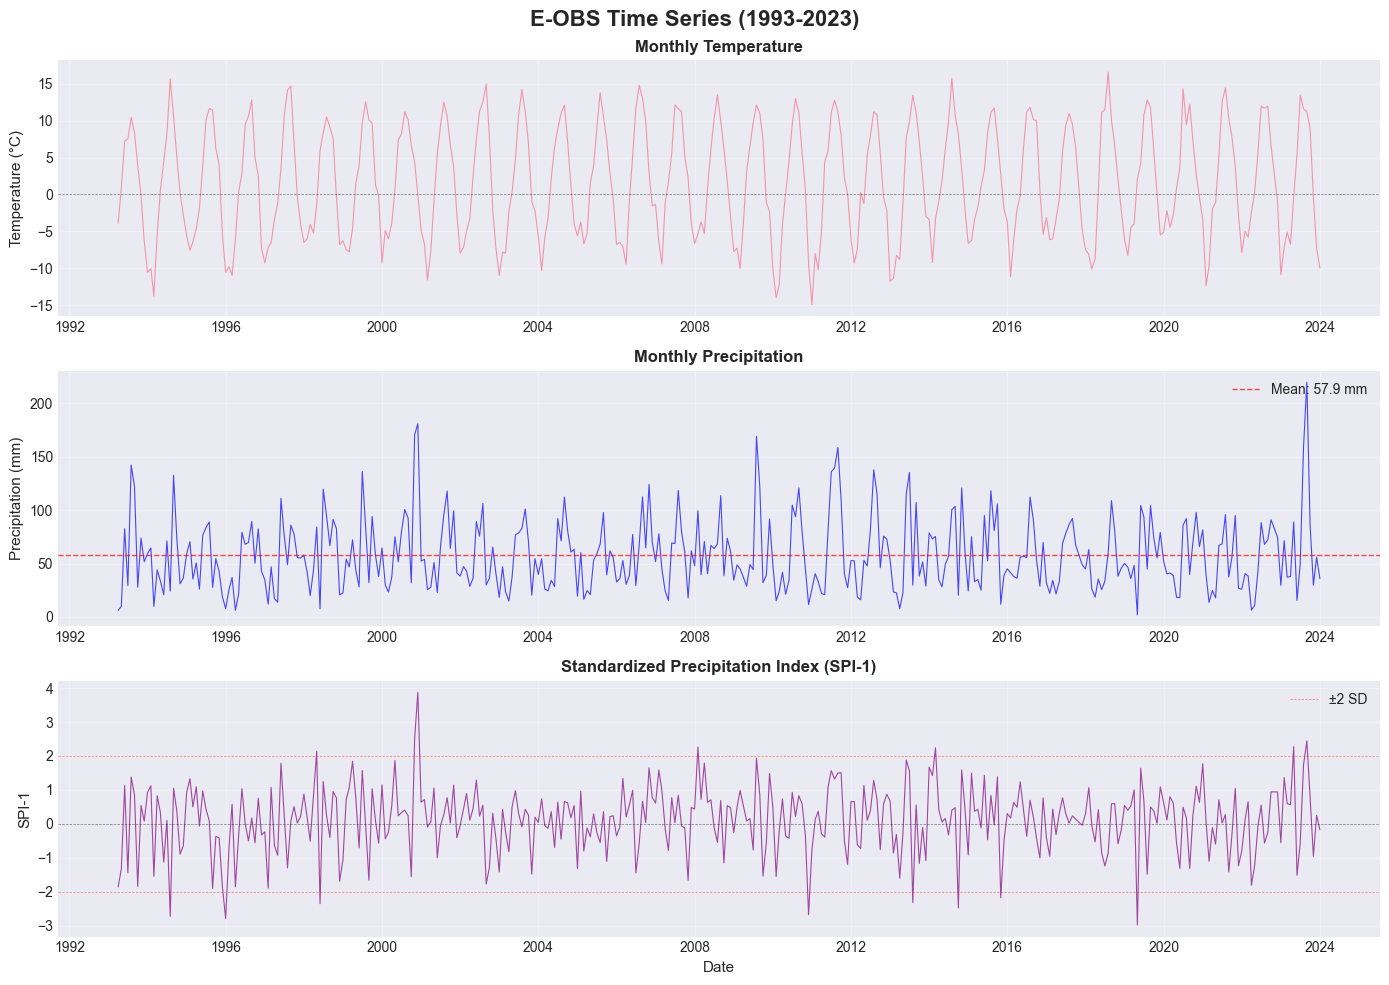

✓ Time series plots complete


In [34]:
# Plot time series of key E-OBS variables
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('E-OBS Time Series (1993-2023)', fontsize=16, fontweight='bold')

# Temperature
axes[0].plot(df['time'], df['eobs_temp'], linewidth=0.8, alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
axes[0].set_ylabel('Temperature (°C)', fontsize=11)
axes[0].set_title('Monthly Temperature', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Precipitation
axes[1].plot(df['time'], df['eobs_precip'], linewidth=0.8, alpha=0.7, color='blue')
axes[1].axhline(y=df['eobs_precip'].mean(), color='red', linestyle='--', 
                linewidth=1, alpha=0.7, label=f'Mean: {df["eobs_precip"].mean():.1f} mm')
axes[1].set_ylabel('Precipitation (mm)', fontsize=11)
axes[1].set_title('Monthly Precipitation', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# SPI-1
axes[2].plot(df['time'], df['eobs_spi_1_values'], linewidth=0.8, alpha=0.7, color='purple')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
axes[2].axhline(y=2, color='red', linestyle='--', linewidth=0.5, alpha=0.5, label='±2 SD')
axes[2].axhline(y=-2, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
axes[2].set_ylabel('SPI-1', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].set_title('Standardized Precipitation Index (SPI-1)', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Time series plots complete")

In [ ]:
# Response variables (what we want to predict)
responses = ['eobs_wet_day_frequency', 'eobs_spi_1_values']

# Predictor variables (what we use to predict)
# 1. Lagged E-OBS observations
lag_predictors = [c for c in df.columns if c.startswith('eobs_') and ('-1' in c or '-2' in c)]

# 2. ECMWF forecasts (ensemble mean)
ecmwf_predictors = [c for c in df.columns if 'ecmwf_' in c and 'ensmean' in c]

# 3. Current E-OBS observations (baseline - what if we had perfect current obs?)
current_eobs = ['eobs_temp', 'eobs_precip', 'eobs_press']

# All predictors
all_predictors = lag_predictors + ecmwf_predictors + current_eobs

PREDICTIVE MODELING SETUP

Response Variables (2):
  - eobs_wet_day_frequency
  - eobs_spi_1_values

Lagged E-OBS Predictors (6):
  - eobs_precip_-1
  - eobs_precip_-2
  - eobs_press_-1
  - eobs_press_-2
  - eobs_temp_-1
  - eobs_temp_-2

ECMWF Forecast Predictors (3):
  - ecmwf_precip_ensmean
  - ecmwf_press_ensmean
  - ecmwf_temp_ensmean

Current E-OBS (Baseline) (3):
  - eobs_temp
  - eobs_precip
  - eobs_press

Total predictors: 12


## Scatter Plots: Top Predictors vs Responses


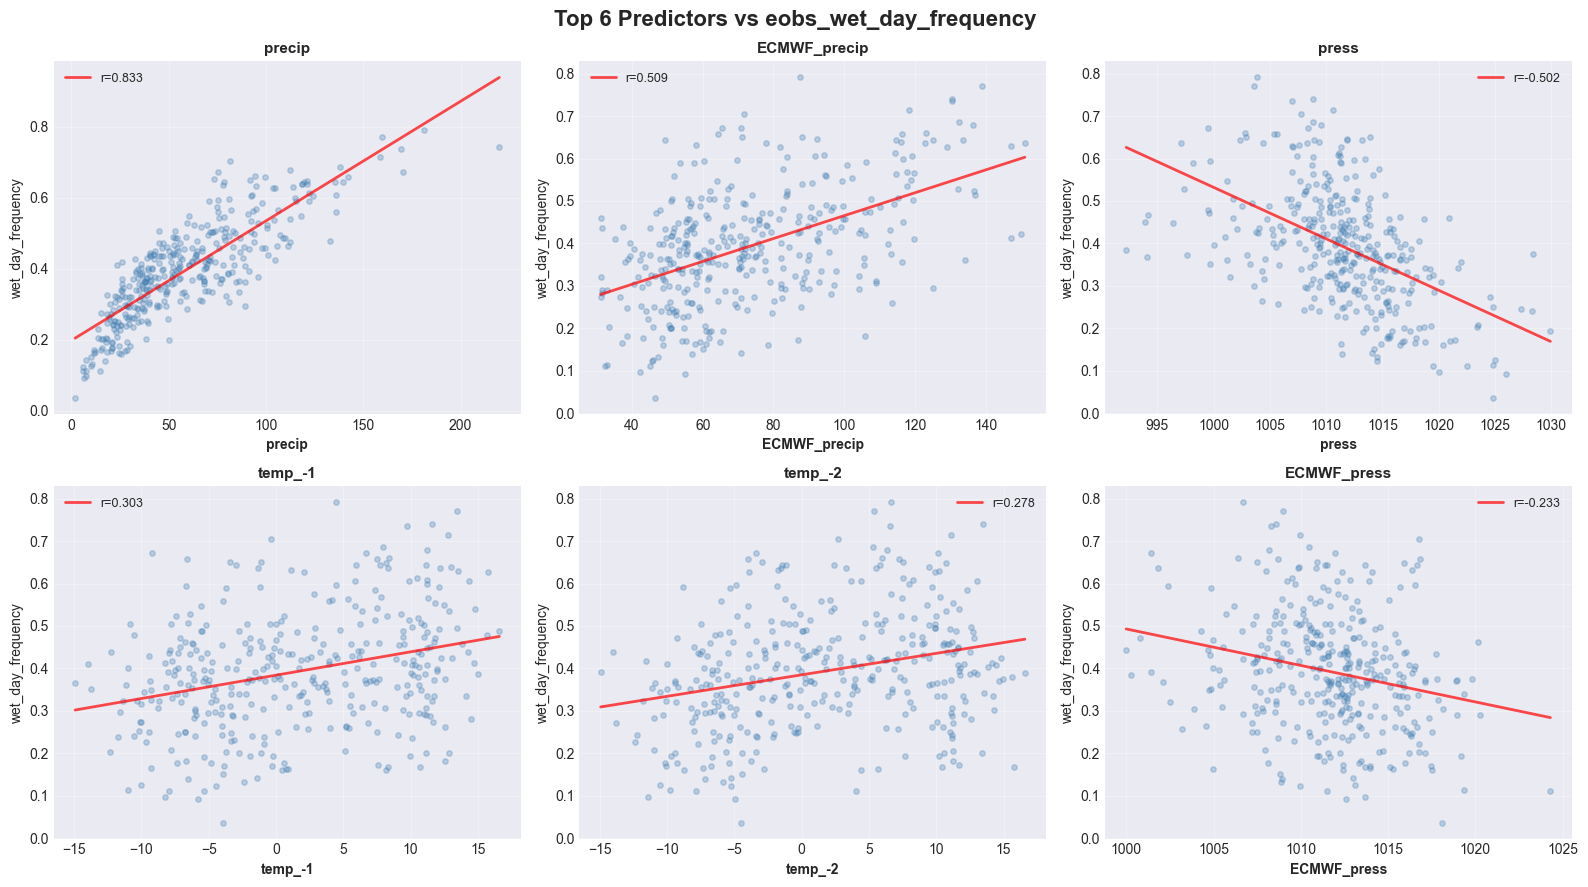

✓ Scatter plots for eobs_wet_day_frequency complete
  Note: These show linearity of relationships - important for model selection


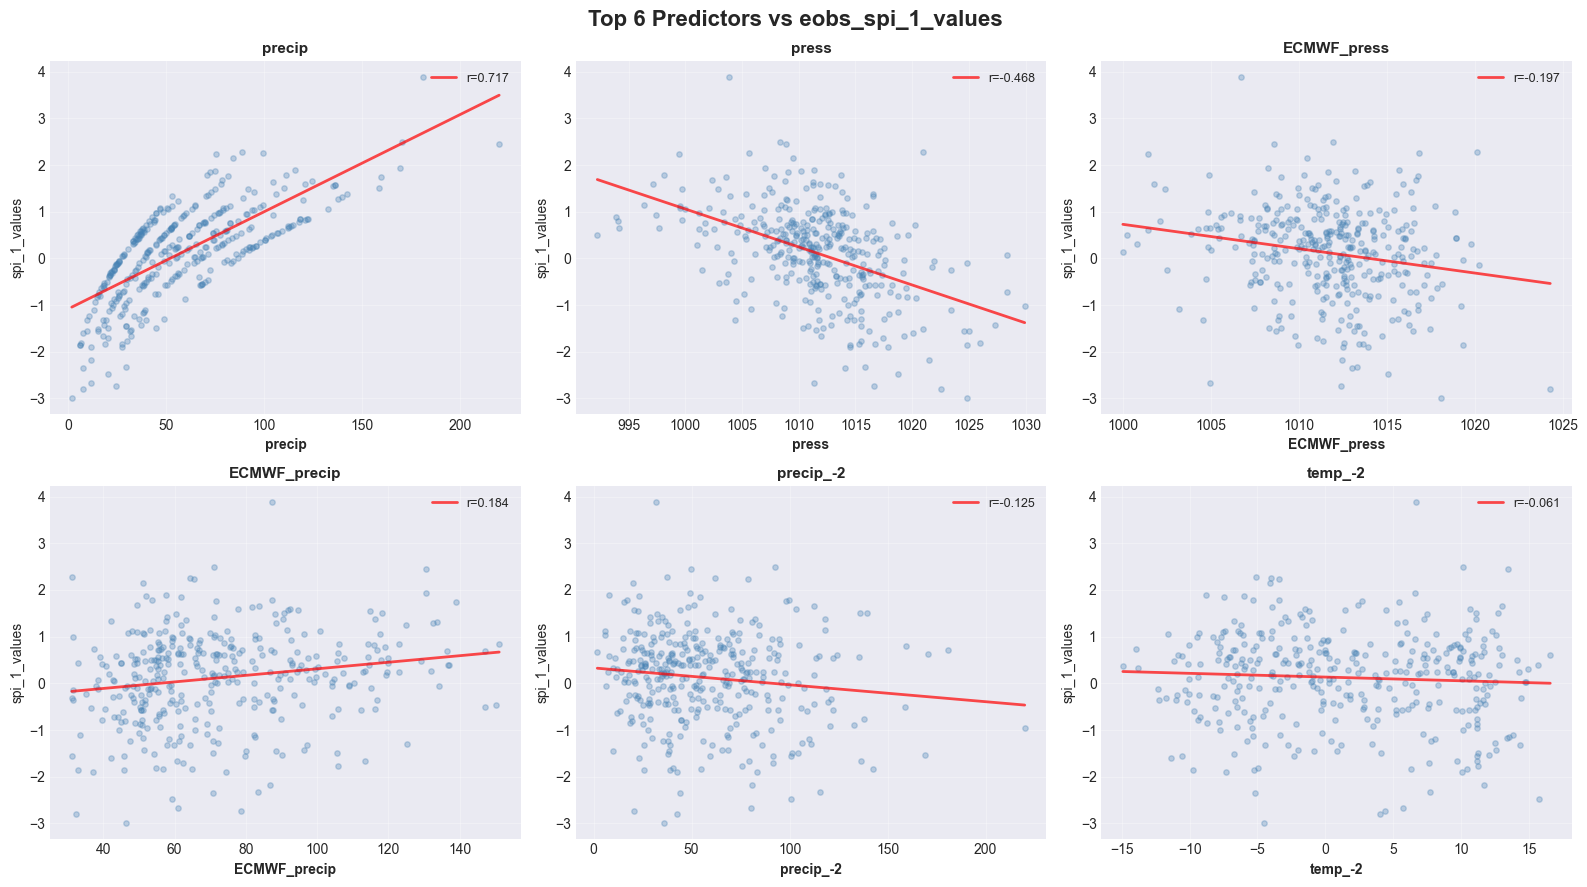

✓ Scatter plots for eobs_spi_1_values complete
  Note: These show linearity of relationships - important for model selection


In [ ]:
for response in responses:
    correlations = {pred: abs(df[pred].corr(df[response])) for pred in all_predictors}
    top_6 = sorted(correlations.items(), key=lambda x: x[1], reverse=True)[:6]
    top_pred_names = [p[0] for p in top_6]
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f'Top 6 Predictors vs {response}', fontsize=16, fontweight='bold')
    
    for ax, pred_name in zip(axes.flatten(), top_pred_names):
        # Scatter plot
        ax.scatter(df[pred_name], df[response], alpha=0.3, s=15, c='steelblue')
        
        slope, intercept, r_value, _, _ = stats.linregress(df[pred_name], df[response])
        x_line = np.array([df[pred_name].min(), df[pred_name].max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'r-', linewidth=2, alpha=0.7, 
                label=f'r={df[pred_name].corr(df[response]):.3f}')
        
        # Clean up predictor name for display
        display_name = pred_name.replace('eobs_', '').replace('ecmwf_', 'ECMWF_').replace('_ensmean', '')
        
        ax.set_xlabel(display_name, fontsize=10, fontweight='bold')
        ax.set_ylabel(response.replace('eobs_', ''), fontsize=10)
        ax.set_title(f'{display_name}', fontsize=11, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Correlation Matrices by Season


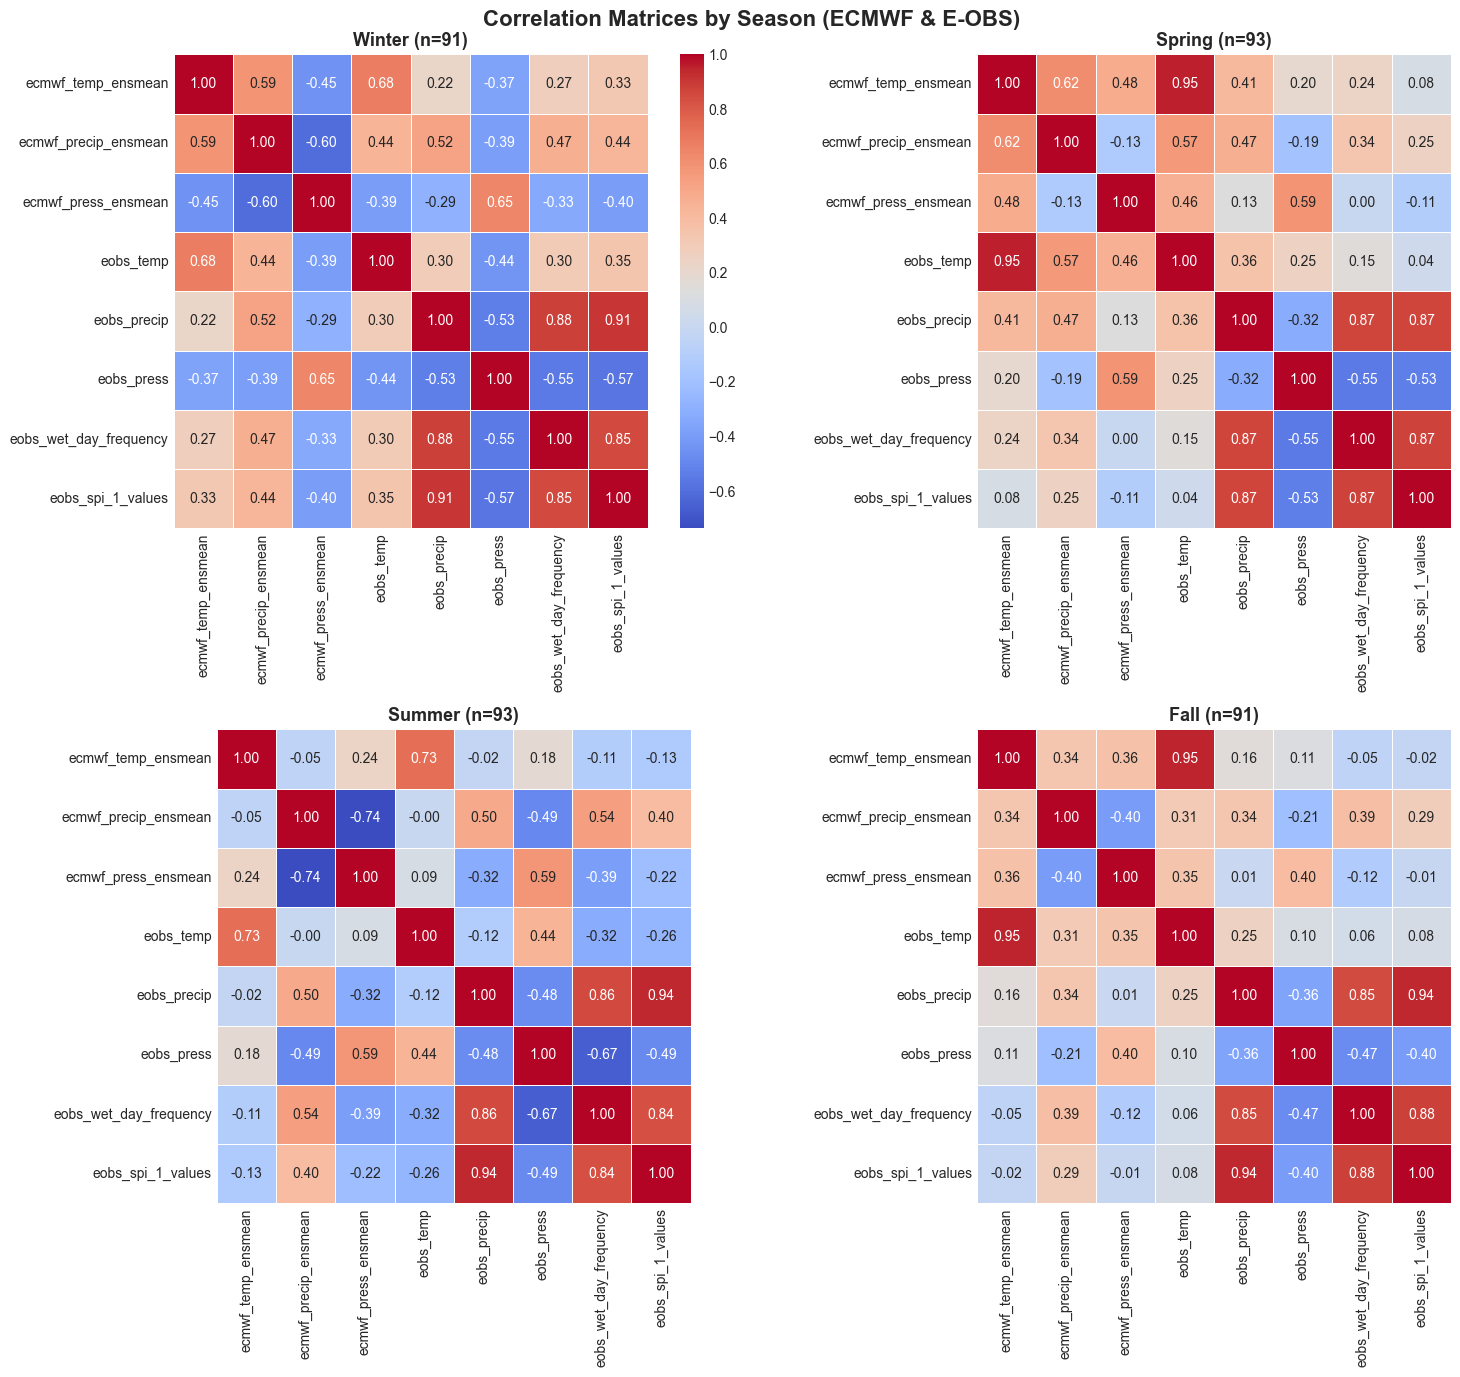

✓ Correlation matrices complete


In [ ]:
selected_columns = [
    "ecmwf_temp_ensmean", "ecmwf_precip_ensmean", "ecmwf_press_ensmean",
    "eobs_temp", "eobs_precip", "eobs_press",
    "eobs_wet_day_frequency", "eobs_spi_1_values"
]

correlation_matrices = {}
for season in ["Winter", "Spring", "Summer", "Fall"]:
    season_df = df[df['season'] == season]
    correlation_matrices[season] = season_df[selected_columns].corr()

all_corr_values = [corr.values.flatten() for corr in correlation_matrices.values()]
all_corr_values = np.concatenate(all_corr_values)
all_corr_values = all_corr_values[~np.isnan(all_corr_values)]
global_vmin = all_corr_values.min()
global_vmax = all_corr_values.max()

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Correlation Matrices by Season (ECMWF & E-OBS)', fontsize=16, fontweight='bold')

seasons = ["Winter", "Spring", "Summer", "Fall"]
for ax, season in zip(axes.flatten(), seasons):
    sns.heatmap(
        correlation_matrices[season],
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=global_vmin,
        vmax=global_vmax,
        linewidths=0.5,
        ax=ax,
        cbar=(ax==axes[0,0]),  # Only show colorbar on first plot
        square=True
    )
    ax.set_title(f"{season} (n={len(df[df['season']==season])})", 
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()